### Coarse Heatmap for FICO×DTI default-rate

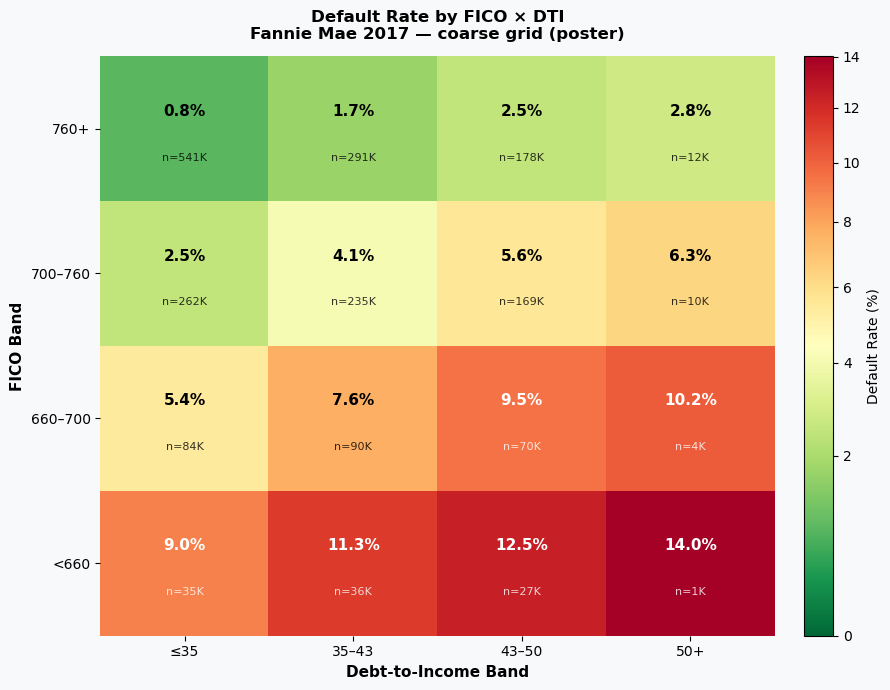

Default rate % (rows=FICO, cols=DTI):
dti_band    ≤35  35–43  43–50    50+
fico_band                           
760+       0.85   1.70   2.49   2.80
700–760    2.47   4.11   5.58   6.30
660–700    5.41   7.60   9.51  10.20
<660       9.03  11.34  12.46  14.02 

Cell counts:
dti_band      ≤35   35–43   43–50    50+
fico_band                               
760+       540579  291130  177649  11734
700–760    261785  234621  168963  10362
660–700     84052   90130   70347   4166
<660        34795   36368   26845   1419


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = pd.read_parquet("../data/processed/fannie_2017_clean.parquet")
df["CSCORE_B"]     = pd.to_numeric(df["CSCORE_B"], errors="coerce")
df["DTI"]          = pd.to_numeric(df["DTI"], errors="coerce")
df["default_flag"] = df["default_flag"].astype(float)

# Coarse bins chosen at Block 2's breakpoints (FICO cliff ~700; DTI accel >40)
# and the 43% QM/ATR regulatory threshold.
fico_edges = [300, 660, 700, 760, 850]
fico_lbls  = ["<660", "660–700", "700–760", "760+"]
dti_edges  = [0, 35, 43, 50, 65]
dti_lbls   = ["≤35", "35–43", "43–50", "50+"]

df["fico_band"] = pd.cut(df["CSCORE_B"], bins=fico_edges, labels=fico_lbls, right=False)
df["dti_band"]  = pd.cut(df["DTI"],      bins=dti_edges,  labels=dti_lbls,  right=False)

# default-rate grid and count grid
rate = df.pivot_table("default_flag", "fico_band", "dti_band", aggfunc="mean",  observed=True) * 100
cnt  = df.pivot_table("default_flag", "fico_band", "dti_band", aggfunc="count", observed=True)

# order rows worst-risk (low FICO) at top
rate = rate.reindex(fico_lbls[::-1]); cnt = cnt.reindex(fico_lbls[::-1])

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#f8f9fa")

im = ax.imshow(rate.values, cmap="RdYlGn_r", aspect="auto",
               norm=mcolors.PowerNorm(gamma=0.6, vmin=0, vmax=np.nanmax(rate.values)))

ax.set_xticks(range(len(dti_lbls)));  ax.set_xticklabels(dti_lbls)
ax.set_yticks(range(len(fico_lbls))); ax.set_yticklabels(fico_lbls[::-1])
ax.set_xlabel("Debt-to-Income Band", fontsize=11, fontweight="bold")
ax.set_ylabel("FICO Band",           fontsize=11, fontweight="bold")
ax.set_title("Default Rate by FICO × DTI\nFannie Mae 2017 — coarse grid (poster)",
             fontsize=12, fontweight="bold", pad=12)

# annotate each cell: rate% on top, n below
for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        r, n = rate.values[i, j], cnt.values[i, j]
        if np.isnan(r):
            continue
        txt_color = "white" if r > np.nanmax(rate.values) * 0.55 else "black"
        ax.text(j, i - 0.12, f"{r:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color=txt_color)
        ax.text(j, i + 0.20, f"n={n/1000:.0f}K", ha="center", va="center",
                fontsize=8, color=txt_color, alpha=0.8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Default Rate (%)", fontsize=10)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

# print the grid so the numbers are inspectable, not just visual
print("Default rate % (rows=FICO, cols=DTI):"); print(rate.round(2), "\n")
print("Cell counts:"); print(cnt.astype(int))


### Fig. 6: Default rate by FICO × DTI (coarse grid)
- Default risk is monotonic in both dimensions: it rises across every DTI band within each FICO row and across every FICO band within each DTI column, with no reversals. 

- The spread from the safest corner (760+ FICO, DTI ≤35: 0.85%) to the riskiest (<660 FICO, DTI 50+: 14.0%) is roughly 16-fold. The two factors interact super-additively  

- In absolute terms the high-DTI penalty grows as FICO weakens (from ~2 points in the 760+ band to ~5 points below 660), so weak credit and high leverage compound rather than simply add. The 50+ DTI column is thinly populated (n≈28K, and just 1,419 in the riskiest cell), so that column's rates are directionally clear but less precisely estimated 

## Figure 7: First-time buyer default premium within FICO × DTI cells

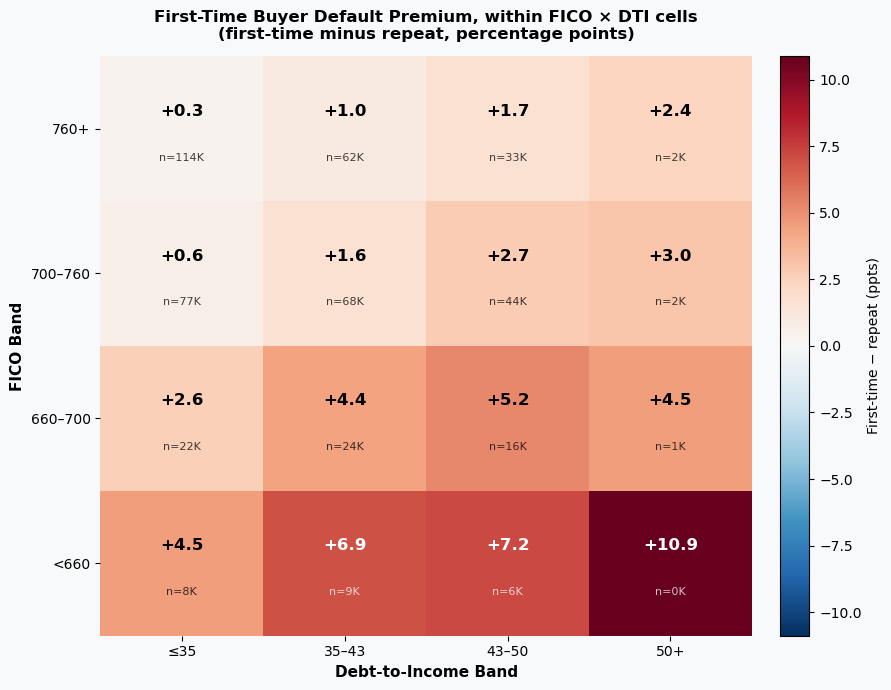

Unadjusted: first-time 4.84% vs repeat 2.97% (gap +1.87 ppts)
Within-cell mean gap (composition-held-fixed): +3.73 ppts

Per-cell gap (ppts, first-time minus repeat):
dti_band    ≤35  35–43  43–50    50+
fico_band                           
760+       0.34   1.00   1.69   2.35
700–760    0.60   1.65   2.73   3.00
660–700    2.62   4.35   5.19   4.54
<660       4.53   6.93   7.20  10.89


In [3]:
# First-time vs repeat buyers WITHIN each FICO×DTI cell.
# Block 2 showed first-timers default at 4.84% overall (63% above base).
# Question: is that a genuine effect, or just worse FICO/DTI composition?

df["is_first_time"] = pd.to_numeric(df["is_first_time"], errors="coerce")

# reuse the exact coarse bands from Figure 6
sub = df.dropna(subset=["fico_band", "dti_band", "is_first_time"]).copy()

# default rate per cell, split by first-time status
grp = (sub.groupby(["fico_band", "dti_band", "is_first_time"], observed=True)["default_flag"]
          .agg(["mean", "count"]).reset_index())
grp["pct"] = grp["mean"] * 100

# pivot to first-time vs repeat, then take the difference (ppts)
ft   = grp[grp.is_first_time == 1].pivot(index="fico_band", columns="dti_band", values="pct")
rep  = grp[grp.is_first_time == 0].pivot(index="fico_band", columns="dti_band", values="pct")
diff = (ft - rep).reindex(fico_lbls[::-1])   # positive = first-timers riskier
ftn  = grp[grp.is_first_time == 1].pivot(index="fico_band", columns="dti_band", values="count").reindex(fico_lbls[::-1])

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#f8f9fa")
lim = np.nanmax(np.abs(diff.values))
im = ax.imshow(diff.values, cmap="RdBu_r", aspect="auto", vmin=-lim, vmax=lim)  # diverging, centered at 0

ax.set_xticks(range(len(dti_lbls)));  ax.set_xticklabels(dti_lbls)
ax.set_yticks(range(len(fico_lbls))); ax.set_yticklabels(fico_lbls[::-1])
ax.set_xlabel("Debt-to-Income Band", fontsize=11, fontweight="bold")
ax.set_ylabel("FICO Band", fontsize=11, fontweight="bold")
ax.set_title("First-Time Buyer Default Premium, within FICO × DTI cells\n"
             "(first-time minus repeat, percentage points)", fontsize=12, fontweight="bold", pad=12)

for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        d, n = diff.values[i, j], ftn.values[i, j]
        if np.isnan(d):
            continue
        ax.text(j, i - 0.12, f"{d:+.1f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if abs(d) > lim * 0.55 else "black")
        ax.text(j, i + 0.20, f"n={n/1000:.0f}K", ha="center", va="center",
                fontsize=8, alpha=0.75,
                color="white" if abs(d) > lim * 0.55 else "black")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("First-time − repeat (ppts)", fontsize=10)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

# overall gap for reference, plus the within-cell average (composition-adjusted)
overall_ft  = sub.loc[sub.is_first_time == 1, "default_flag"].mean() * 100
overall_rep = sub.loc[sub.is_first_time == 0, "default_flag"].mean() * 100
print(f"Unadjusted: first-time {overall_ft:.2f}% vs repeat {overall_rep:.2f}% "
      f"(gap {overall_ft - overall_rep:+.2f} ppts)")
print(f"Within-cell mean gap (composition-held-fixed): {np.nanmean(diff.values):+.2f} ppts")
print("\nPer-cell gap (ppts, first-time minus repeat):"); print(diff.round(2))

In [4]:
# loan-weighted within-cell gap: reweight cell gaps by first-time loan counts,
# excluding cells too thin to estimate (guard against the n≈0 corner)
w = ftn.copy()
mask = w >= 500                      # require ≥500 first-time loans in the cell
weighted_gap = np.nansum((diff * w).values[mask.values]) / np.nansum(w.values[mask.values])
print(f"Loan-weighted within-cell gap (cells with n≥500): {weighted_gap:+.2f} ppts")

# also report the range across well-populated cells, not the thin corner
solid = diff.where(ftn >= 500)
print(f"Range across solid cells: {np.nanmin(solid.values):+.2f} to {np.nanmax(solid.values):+.2f} ppts")

Loan-weighted within-cell gap (cells with n≥500): +1.71 ppts
Range across solid cells: +0.34 to +7.20 ppts


### Fig. 7: First-time buyer default premium within FICO × DTI cells
- Each cell shows the first-time-minus-repeat default rate (percentage points) for borrowers sharing the same FICO and DTI band, isolating the effect of first-time status from differences in creditworthiness. 

- The premium is positive in all sixteen cells, so Block 2's overall first-time gap (4.84% vs 2.97%) is not an artifact of first-time buyers carrying weaker fundamentals: it persists after holding FICO and DTI fixed, at a loan-weighted premium of +1.71 percentage points. 

- The premium also scales with risk, from +0.34 points among prime, low-leverage borrowers to +7.20 in well-populated subprime, high-DTI cells, indicating that first-time status amplifies other risk factors rather than adding a constant offset. 

- The 50+ DTI / <660 FICO cell (+10.9) rests on essentially no first-time loans and is not interpreted.

## Figure 8: Default rate by FICO × LTV (coarse grid) 

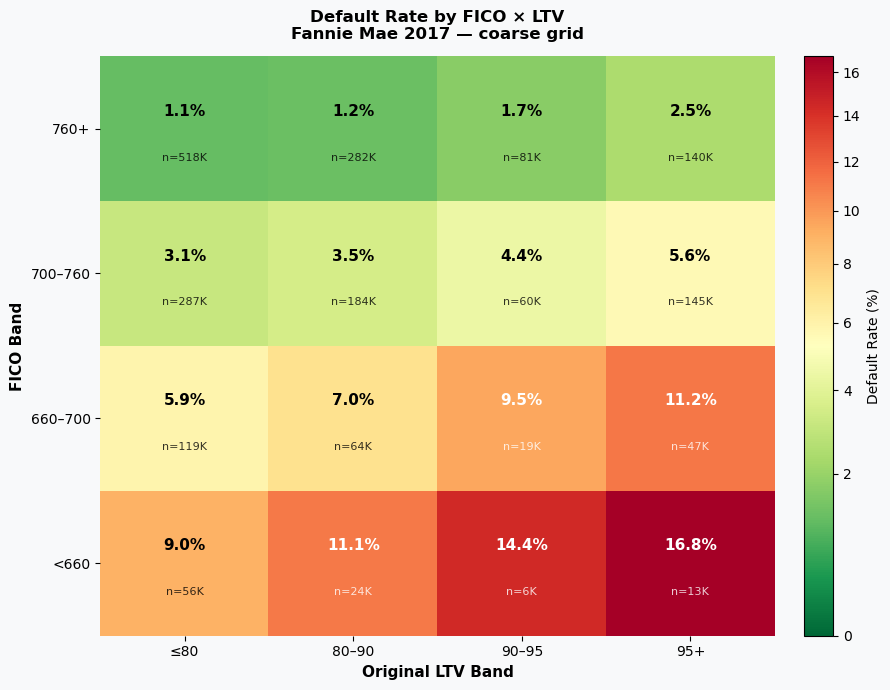

Default rate % (rows=FICO, cols=LTV):
ltv_band    ≤80  80–90  90–95    95+
fico_band                           
760+       1.14   1.25   1.73   2.45
700–760    3.14   3.50   4.43   5.59
660–700    5.88   7.04   9.48  11.15
<660       9.01  11.11  14.42  16.77 

Cell counts:
ltv_band      ≤80   80–90  90–95     95+
fico_band                               
760+       517926  282183  80562  140421
700–760    286847  184152  60063  144669
660–700    118827   63994  19264   46610
<660        56201   24202   5681   13343


In [5]:
# LTV × FICO — third leg of the FICO/DTI/LTV triangle.
# Coarse LTV bands at 80 (MI threshold) and 95 (Block 2's high-LTV cliff).
df["OLTV"] = pd.to_numeric(df["OLTV"], errors="coerce")

ltv_edges = [0, 80, 90, 95, 101]          # 101 so a 100 LTV lands inside
ltv_lbls  = ["≤80", "80–90", "90–95", "95+"]
df["ltv_band"] = pd.cut(df["OLTV"], bins=ltv_edges, labels=ltv_lbls, right=False)

# reuse the exact FICO bands from Figure 6
rate = df.pivot_table("default_flag", "fico_band", "ltv_band", aggfunc="mean",  observed=True) * 100
cnt  = df.pivot_table("default_flag", "fico_band", "ltv_band", aggfunc="count", observed=True)
rate = rate.reindex(fico_lbls[::-1]); cnt = cnt.reindex(fico_lbls[::-1])

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#f8f9fa")
im = ax.imshow(rate.values, cmap="RdYlGn_r", aspect="auto",
               norm=mcolors.PowerNorm(gamma=0.6, vmin=0, vmax=np.nanmax(rate.values)))

ax.set_xticks(range(len(ltv_lbls)));  ax.set_xticklabels(ltv_lbls)
ax.set_yticks(range(len(fico_lbls))); ax.set_yticklabels(fico_lbls[::-1])
ax.set_xlabel("Original LTV Band", fontsize=11, fontweight="bold")
ax.set_ylabel("FICO Band", fontsize=11, fontweight="bold")
ax.set_title("Default Rate by FICO × LTV\nFannie Mae 2017 — coarse grid",
             fontsize=12, fontweight="bold", pad=12)

for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        r, n = rate.values[i, j], cnt.values[i, j]
        if np.isnan(r): continue
        c = "white" if r > np.nanmax(rate.values) * 0.55 else "black"
        ax.text(j, i - 0.12, f"{r:.1f}%",   ha="center", va="center", fontsize=11, fontweight="bold", color=c)
        ax.text(j, i + 0.20, f"n={n/1000:.0f}K", ha="center", va="center", fontsize=8, color=c, alpha=0.8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Default Rate (%)", fontsize=10)
ax.spines[["top","right","left","bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

print("Default rate % (rows=FICO, cols=LTV):"); print(rate.round(2), "\n")
print("Cell counts:"); print(cnt.astype(int))

### Fig. 8: Default rate by FICO × LTV (coarse grid) 
- Completing the FICO/DTI/LTV risk triangle, this grid shows the same super-additive structure as Fig. 6, default risk is monotonic in both dimensions with no reversals

- The high-LTV penalty widens as credit weakens from +1.3 percentage points for prime borrowers (760+) to +7.8 points for subprime (<660). 

- The spread from the safest corner (760+ FICO, ≤80 LTV: 1.14%) to the riskiest (<660 FICO, 95+ LTV: 16.77%) is roughly 15-fold, and unlike the 50+ DTI column, every cell here is well populated (minimum n≈6K). 

- That FICO amplifies both DTI and LTV risk identically indicates it acts as a broad risk multiplier rather than an additive factor. This is evidence that an additive PD model would understate risk in the worst segments, and that the joint low-FICO/high-LTV segment (not either factor alone) is the natural target for the LP's diversification constraints.

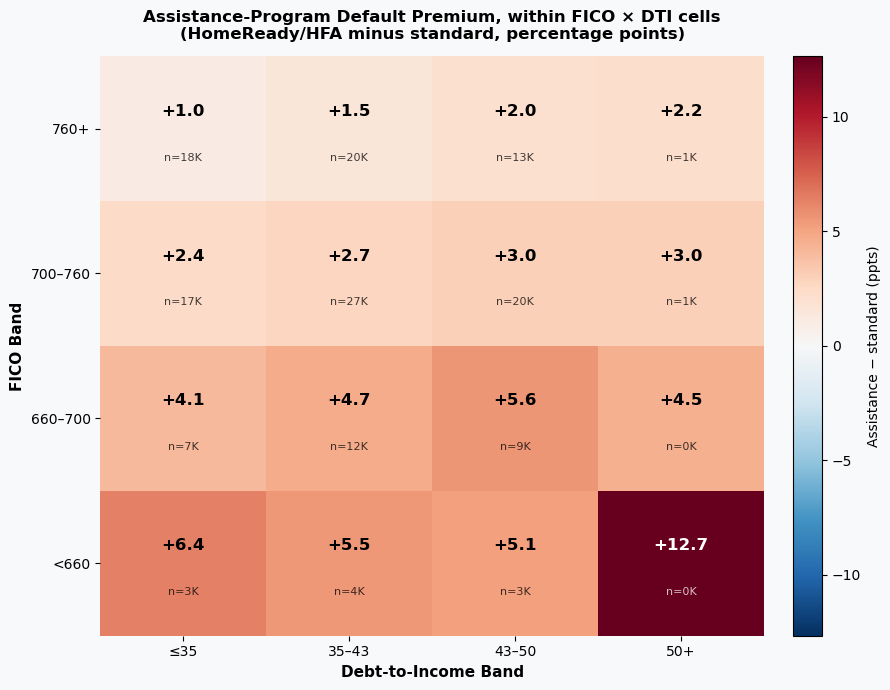

Unadjusted: assistance 7.02% vs standard 3.12% (gap +3.91 ppts)
Loan-weighted within-cell gap (n≥500): +2.89 ppts
Assistance loans total: 155,803

Per-cell gap (ppts):
dti_band    ≤35  35–43  43–50    50+
fico_band                           
760+       1.00   1.55   2.01   2.24
700–760    2.43   2.68   3.03   3.00
660–700    4.10   4.71   5.62   4.55
<660       6.36   5.46   5.14  12.66


In [6]:
# Assistance-program premium WITHIN FICO×DTI cells.
# Block 2: HomeReady 5.92%, HFA 9.22% — but these programs target weaker
# borrowers, so raw rates may be pure composition. Test: does the premium
# survive holding FICO/DTI fixed, or vanish?
df["is_assistance"] = ((pd.to_numeric(df["is_homeready"], errors="coerce") == 1) |
                       (pd.to_numeric(df["is_hfa"], errors="coerce") == 1)).astype(int)

sub = df.dropna(subset=["fico_band", "dti_band"]).copy()
grp = (sub.groupby(["fico_band","dti_band","is_assistance"], observed=True)["default_flag"]
          .agg(["mean","count"]).reset_index())
grp["pct"] = grp["mean"] * 100

asst = grp[grp.is_assistance==1].pivot(index="fico_band", columns="dti_band", values="pct")
std  = grp[grp.is_assistance==0].pivot(index="fico_band", columns="dti_band", values="pct")
diff = (asst - std).reindex(fico_lbls[::-1])                      # + = assistance riskier
an   = grp[grp.is_assistance==1].pivot(index="fico_band", columns="dti_band", values="count").reindex(fico_lbls[::-1])

fig, ax = plt.subplots(figsize=(9, 7)); fig.patch.set_facecolor("#f8f9fa")
lim = np.nanmax(np.abs(diff.values))
im = ax.imshow(diff.values, cmap="RdBu_r", aspect="auto", vmin=-lim, vmax=lim)
ax.set_xticks(range(len(dti_lbls)));  ax.set_xticklabels(dti_lbls)
ax.set_yticks(range(len(fico_lbls))); ax.set_yticklabels(fico_lbls[::-1])
ax.set_xlabel("Debt-to-Income Band", fontsize=11, fontweight="bold")
ax.set_ylabel("FICO Band", fontsize=11, fontweight="bold")
ax.set_title("Assistance-Program Default Premium, within FICO × DTI cells\n"
             "(HomeReady/HFA minus standard, percentage points)", fontsize=12, fontweight="bold", pad=12)

for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        d, n = diff.values[i, j], an.values[i, j]
        if np.isnan(d): continue
        c = "white" if abs(d) > lim*0.55 else "black"
        ax.text(j, i-0.12, f"{d:+.1f}", ha="center", va="center", fontsize=12, fontweight="bold", color=c)
        ax.text(j, i+0.20, f"n={n/1000:.0f}K", ha="center", va="center", fontsize=8, alpha=0.75, color=c)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Assistance − standard (ppts)", fontsize=10)
ax.spines[["top","right","left","bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

# unadjusted vs composition-adjusted (loan-weighted, thin cells guarded)
oa = sub.loc[sub.is_assistance==1,"default_flag"].mean()*100
os_= sub.loc[sub.is_assistance==0,"default_flag"].mean()*100
w = an.where(an>=500)
wgap = np.nansum((diff*w).values[~np.isnan(w.values)]) / np.nansum(w.values[~np.isnan(w.values)])
print(f"Unadjusted: assistance {oa:.2f}% vs standard {os_:.2f}% (gap {oa-os_:+.2f} ppts)")
print(f"Loan-weighted within-cell gap (n≥500): {wgap:+.2f} ppts")
print(f"Assistance loans total: {int(sub.is_assistance.sum()):,}")
print("\nPer-cell gap (ppts):"); print(diff.round(2))

### Fig. 9:  Assistance-program default premium within FICO × DTI cells
- Each cell shows the HomeReady/HFA-minus-standard default rate for borrowers sharing a FICO and DTI band, isolating program participation from creditworthiness. Block 2's large raw gap (assistance 7.02% vs standard 3.12%, +3.91 ppts) is only partly composition as roughly a quarter reflects assistance borrowers carrying weaker fundamentals, but the majority survives, at a loan-weighted within-cell premium of +2.89 percentage points. 

- The premium is positive in every populated cell and, as with first-time status, widens as fundamentals weaken (from +1.0 among prime borrowers to +5–6 in well-populated subprime cells). Program participation therefore carries independent risk signal beyond FICO and DTI, rather than being a pure artifact of borrower composition. 

- Two caveats: the <660/50+ cell (+12.7) rests on essentially no assistance loans and is not interpreted; and because assistance programs disproportionately serve first-time buyers, this premium and the first-time premium of Figure 7 partly reflect the same underlying population.

# Block 4 Summary: Bivariate & Interaction Analysis: Summary

Four interaction figures move past the single-variable view of Blocks 2–3. Three findings recur with the same structure: 

- (1) FICO × DTI (Fig 6): risk is monotonic in both factors with no reversals, spanning 0.85% to 14.0%, and the DTI penalty widens as FICO weakens, the factors compound rather than add. 

- (2) FICO × LTV (Fig 8): the same super-additive pattern on well-populated cells throughout, spanning 1.14% to 16.77%, with the high-LTV penalty growing from +1.3 ppts for prime borrowers to +7.8 for subprime. 

- (3) First-time status (Fig 7): a genuine effect, not composition. The premium survives holding FICO/DTI fixed (+1.71 ppts loan-weighted) and scales with risk. (4) Assistance programs (Fig 9): similarly mostly independent signal, with ~74% of the raw HomeReady/HFA gap persisting within matched cells (+2.89 ppts).

The unifying result: weak credit amplifies every other risk factor. DTI, LTV, first-time status, and program participation all hit harder at low FICO than high. This has two direct implications. 

For modeling, an additive/linear PD specification would systematically understate risk in the worst segments, favoring a model that captures interactions natively (e.g. gradient boosting). 

For the LP, the dangerous segment is the joint low-FICO/high-LTV/high-DTI corner, not any single factor, so diversification constraints should target joint segments rather than marginal caps. One caveat carried forward: first-time status and assistance participation overlap substantially, so their premiums are not fully independent.

In [8]:
import pandas as pd

feat  = pd.read_parquet("../data/processed/fannie_2017_features_added.parquet")
clean = pd.read_parquet("../data/processed/fannie_2017_clean.parquet")

fcols, ccols = set(feat.columns), set(clean.columns)

print(f"features_added: {feat.shape[0]:,} rows × {feat.shape[1]} cols")
print(f"clean:          {clean.shape[0]:,} rows × {clean.shape[1]} cols")
print(f"rows dropped:   {feat.shape[0] - clean.shape[0]:,}\n")

print(f"Columns removed in clean ({len(fcols - ccols)}):")
print(sorted(fcols - ccols), "\n")

print(f"Columns added in clean ({len(ccols - fcols)}):")
print(sorted(ccols - fcols))

features_added: 2,046,851 rows × 123 cols
clean:          2,044,946 rows × 57 cols
rows dropped:   1,905

Columns removed in clean (68):
['ADR_COUNT', 'ADR_TYPE', 'ADR_UPB', 'ARM_5_YR_INDICATOR', 'ARM_CAP_STRUCTURE', 'ARM_INDEX', 'ARM_PRODUCT_TYPE', 'ASSET_RECOVERY_COSTS', 'ASSOCIATED_TAXES_FOR_HOLDING_PROPERTY', 'BALLOON_INDICATOR', 'CREDIT_ENHANCEMENT_PROCEEDS', 'CUMULATIVE_CREDIT_EVENT_NET_GAIN_OR_LOSS', 'CUMULATIVE_MODIFICATION_LOSS_AMOUNT', 'CURRENT_LIST_PRICE', 'CURRENT_LIST_START_DATE', 'CURRENT_PERIOD_CREDIT_EVENT_NET_GAIN_OR_LOSS', 'CURRENT_PERIOD_MODIFICATION_LOSS_AMOUNT', 'CURR_CLASSIC_FICO', 'CURR_SCHD_PRNCPL', 'CURR_SCOREB', 'CURR_SCOREC', 'DEAL_NAME', 'DELINQUENT_ACCRUED_INTEREST', 'DISPOSITION_DATE', 'FIRST_PAY_IO', 'FORBEARANCE_INDICATOR', 'FORECLOSURE_COSTS', 'FORECLOSURE_DATE', 'FORECLOSURE_PRINCIPAL_WRITE_OFF_AMOUNT', 'INITIAL_INTEREST_RATE_CAP', 'INTEREST_BEARING_UPB', 'INTEREST_RATE_CHANGE_DATE', 'ISSUANCE_UPB', 'ISSUE_CLASSIC_FICO', 'ISSUE_SCOREB', 'ISSUE_SCOREC',

## clean retains max_dlq_ever and zero_bal_code for EDA; these are label-derived and must be excluded from any model matrix (see FEATURE_ROLES['label_derived'])